In [1]:
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scirpy as ir
import muon as mu
import random
from pathlib import Path

random.seed(10)

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths — relative to this notebook's location (GVHD_Reproducibility-main/Sc&TCR_Pipelines/)
PROJECT_ROOT = Path('../..')

# Input paths
TCELL_ANN_ANNOTATED_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_annotated.h5ad'
RESI_PATH                = PROJECT_ROOT / 'adata_file' / 'Resi.h5ad'
TCR_DATA_DIR             = PROJECT_ROOT / 'filtered_contig_annotations'

# Output paths — figures
FIGURES_SC_DIR           = PROJECT_ROOT / 'Figures' / 'single_cell_figures'

TCELL_ANN_CONCAT_WITH_TCR_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_with_TCR.h5mu'
AIRR_OBS_CSV_PATH        = PROJECT_ROOT / 'adata_file' / 'airr_obs.csv'

In [3]:
# version of scirpy
print(ir.__version__)

0.22.0


In [4]:
tcell_ann = anndata.read_h5ad(TCELL_ANN_ANNOTATED_PATH)

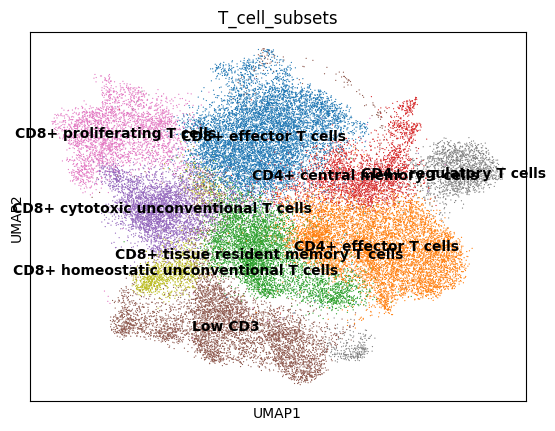

In [5]:
sc.pl.umap(tcell_ann, color=['T_cell_subsets'], legend_loc='on data')

# Load in TCR data

In [6]:
Sample_list = ["R096_Tc17_up","R096_Tc17_low","RH01","RH02","RH03","RH04","RH05","RH06","RH07","RH08","RH09","RH10","RH11","RH12","RH13","RH14","UA01","UA02","UA03","UA04","UA05","UA06","UA07","UA08","UA09","UA10","UA11","UA12",'UA13','UA14','UA15','UA19','UA20','UA21','UA22','UA23','UA24','UA26','UA30','UA31','UA32','UA33','UA34','UA35','UA36','UA37','UA38','UA39','UA40','UA41']
tcell_ann =tcell_ann[tcell_ann.obs["SampleID"].isin(Sample_list)]
tcell_ann.obs["SampleID"].unique()

['R096_Tc17_up', 'R096_Tc17_low', 'RH01', 'RH02', 'RH03', ..., 'UA37', 'UA38', 'UA39', 'UA40', 'UA41']
Length: 50
Categories (50, object): ['R096_Tc17_low', 'R096_Tc17_up', 'RH01', 'RH02', ..., 'UA38', 'UA39', 'UA40', 'UA41']

In [7]:
adatas_tcr = {}
adatas_gex = {}

for sample in Sample_list:
    adata_gex = tcell_ann[tcell_ann.obs["SampleID"]==sample]
    adata_tcr = ir.io.read_10x_vdj(TCR_DATA_DIR / f"{sample}_contig.csv")
    # concat the sample name with the cell barcode in the tcr data
    adata_tcr.obs.index = [ sample + '_' + x for x in adata_tcr.obs.index]
    adatas_tcr[sample] = adata_tcr
    adatas_gex[sample] = adata_gex
    print(sample)

R096_Tc17_up


/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/anndata/utils.py:349: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


R096_Tc17_low
RH01
RH02
RH03
RH04
RH05
RH06
RH07
RH08
RH09
RH10
RH11
RH12
RH13
RH14
UA01
UA02
UA03
UA04
UA05
UA06
UA07
UA08
UA09
UA10
UA11
UA12
UA13
UA14
UA15
UA19
UA20
UA21
UA22
UA23
UA24
UA26
UA30
UA31
UA32
UA33
UA34
UA35
UA36
UA37
UA38
UA39
UA40
UA41


In [8]:
# Merge anndata objects
adata_gex = anndata.concat(adatas_gex, index_unique=None)
adata_tcr = anndata.concat(adatas_tcr, index_unique=None)
mdata = mu.MuData({"gex": adata_gex, "airr": adata_tcr})

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

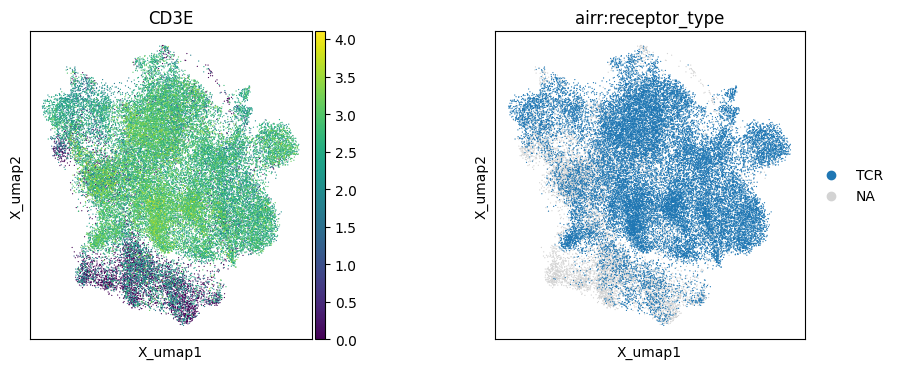

In [10]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"wspace": 0.5})
mu.pl.embedding(mdata, basis="gex:umap", color=["CD3E"], ax=ax0, show=False)
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:receptor_type"], ax=ax1)

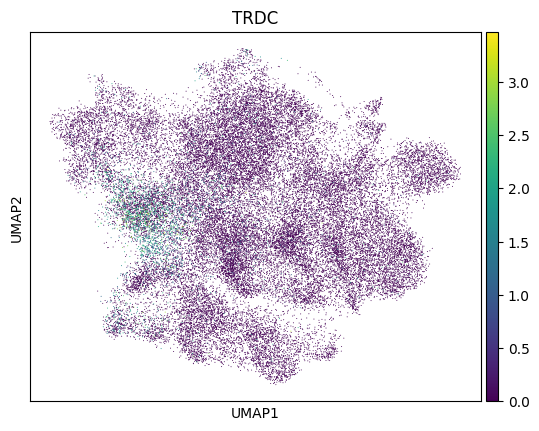

In [11]:
# plot heatmp TRDC for each cluster
sc.pl.umap(mdata["gex"], color=['TRDC'], s =2)

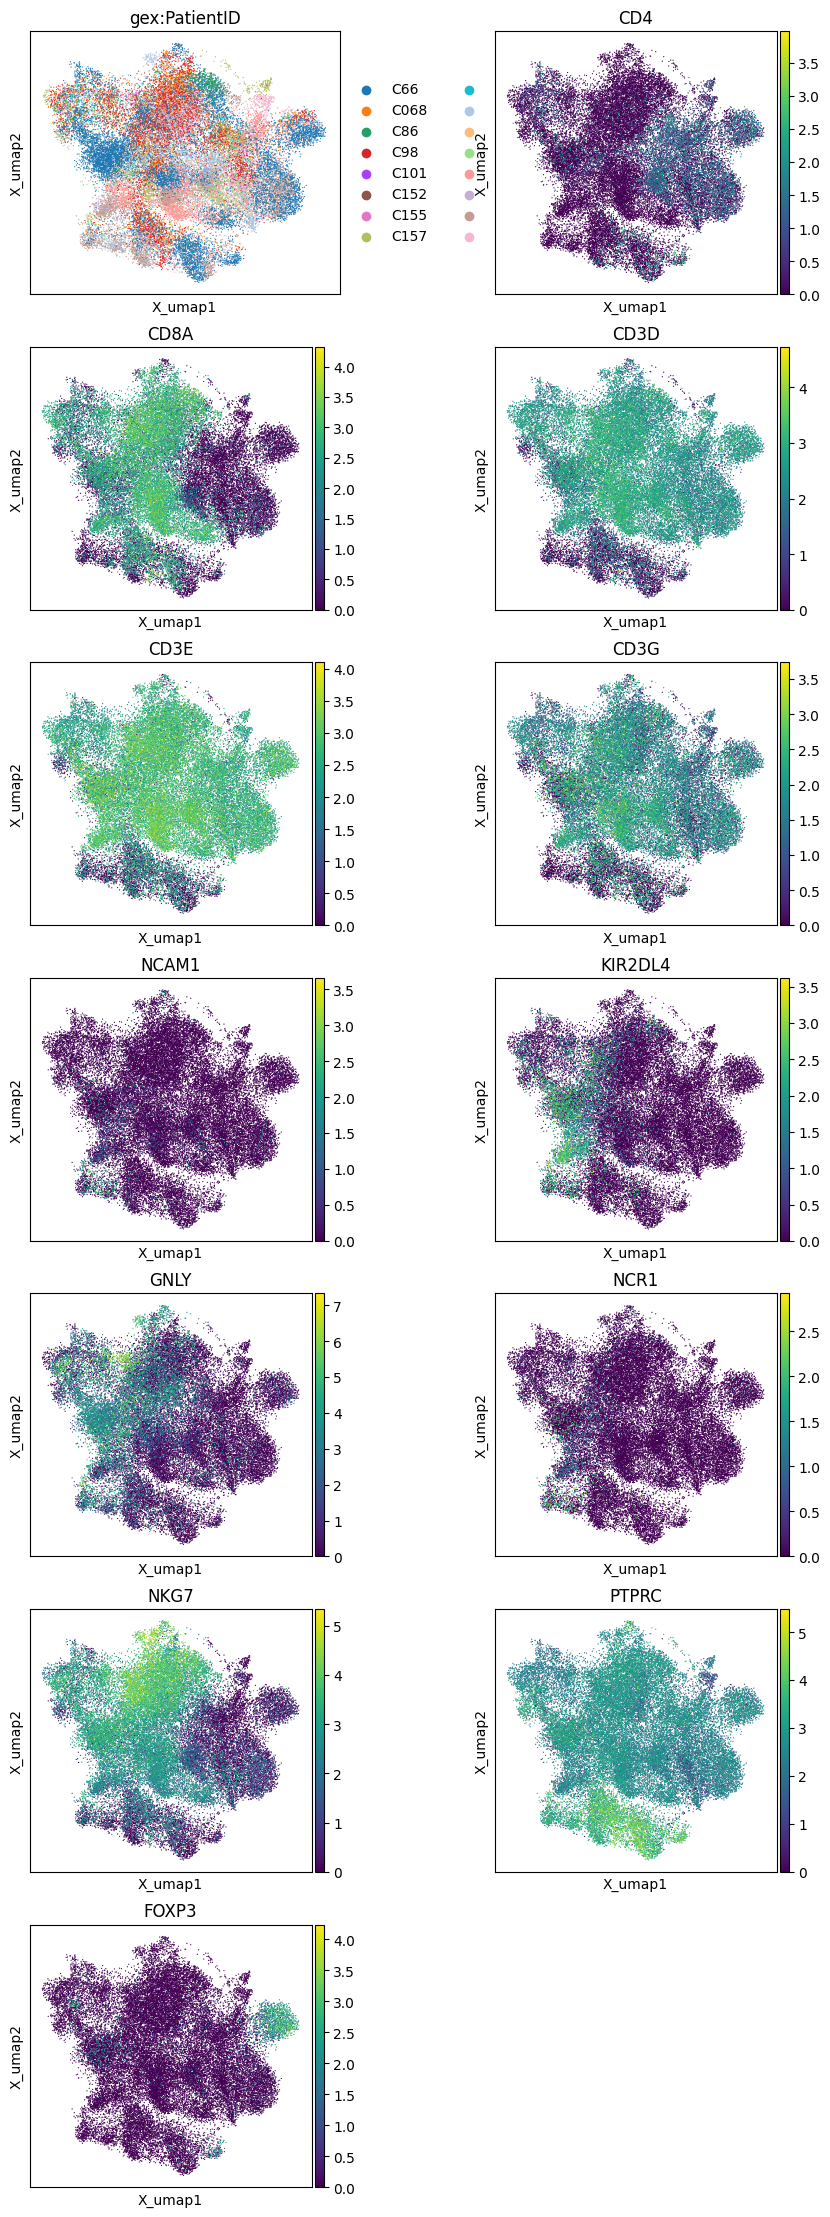

In [12]:
colors = ['PatientID', 'CD4', 'CD8A', 'CD3D', 'CD3E', 'CD3G',
          "NCAM1", "KIR2DL4", "GNLY", "NCR1", "NKG7", "PTPRC", "FOXP3"]
ncols = 2
nrows = (len(colors) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 4),
                         gridspec_kw={"wspace": 0.5})
axes = axes.flatten()

for i, color in enumerate(colors):
    mu.pl.embedding(mdata, basis="gex:umap", color=[f'gex:{color}'], ax=axes[i], show=False)

for j in range(len(colors), len(axes)):
    axes[j].set_visible(False)

plt.show()


In [13]:
parameters = ['PatientID', 'SampleID', 'FreshorFrozen',
       'Days_post-Transplant', 'Tissue_Location', 'LPorIE',
       'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1',
       'GVHD_Grade_2', 'GVHD_Grade_3','Transplant_Conditioning', 'Gender','Time_1stGVHD', 'Donor',
       'Disease', 'GVHD_Prophylaxis_Regimen']

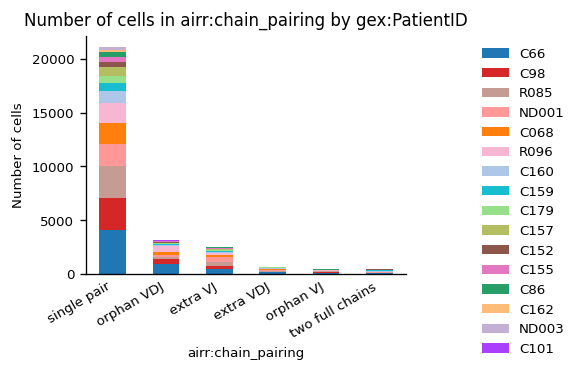

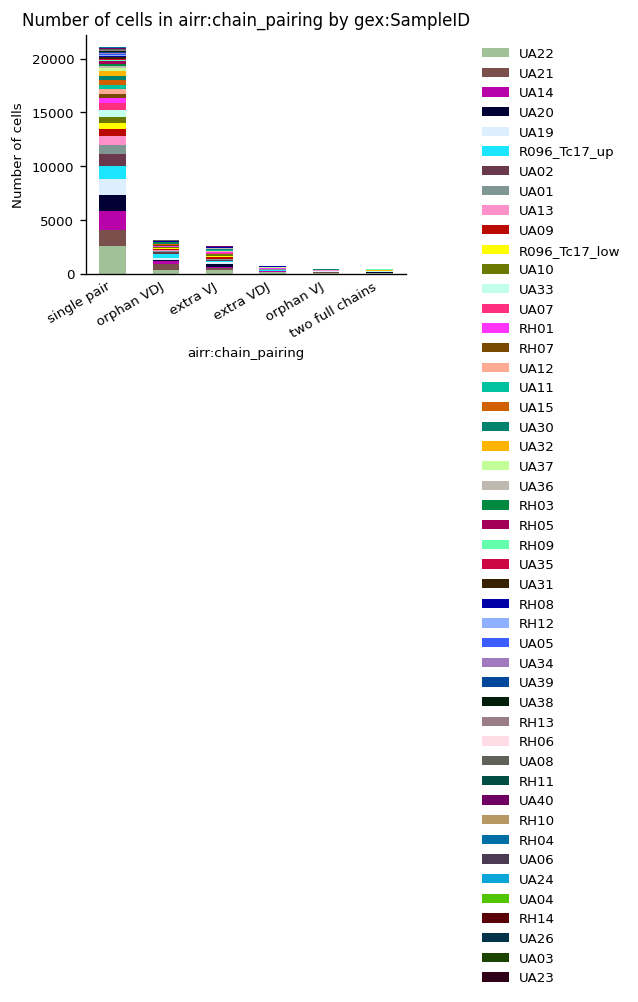

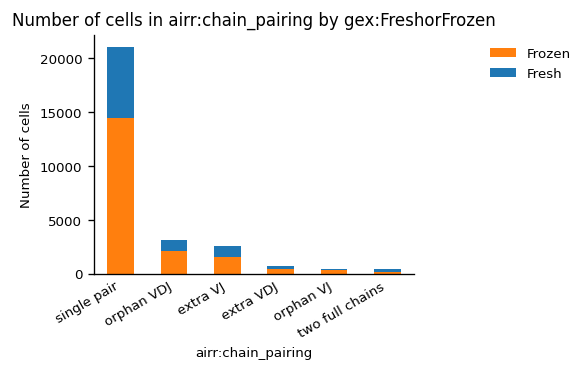

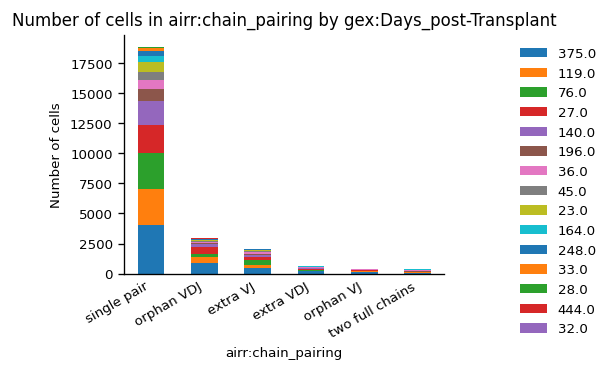

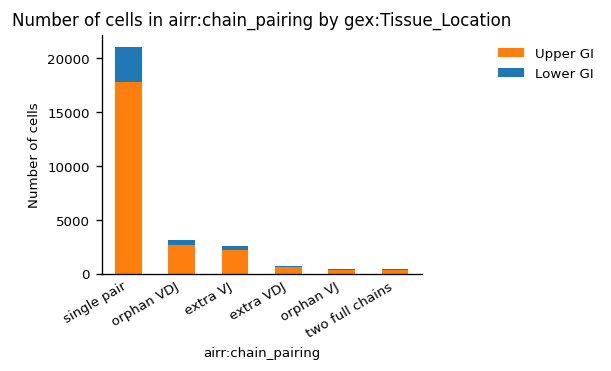

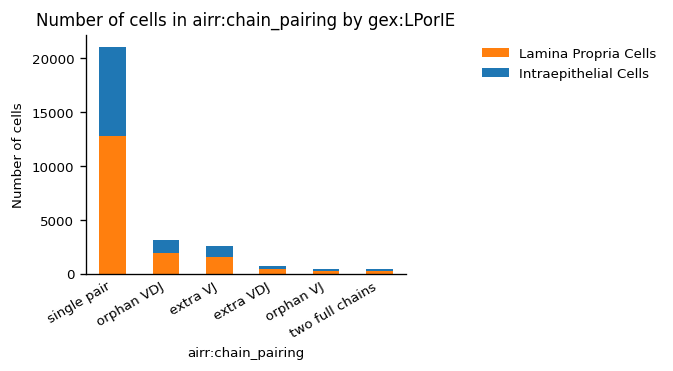

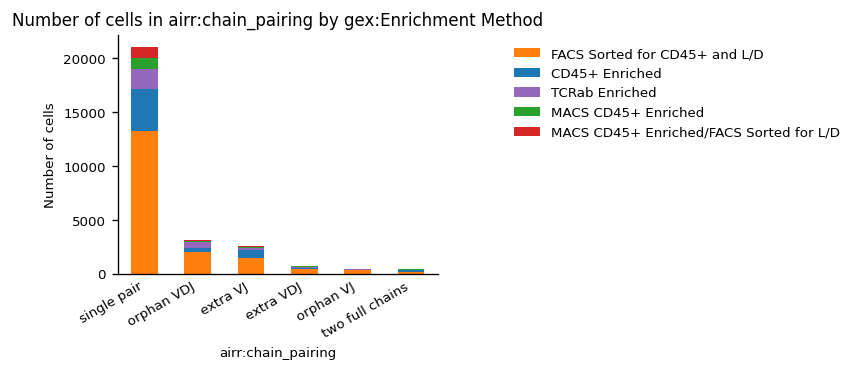

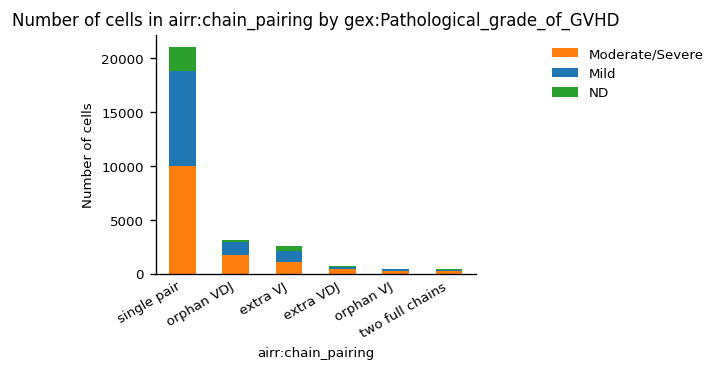

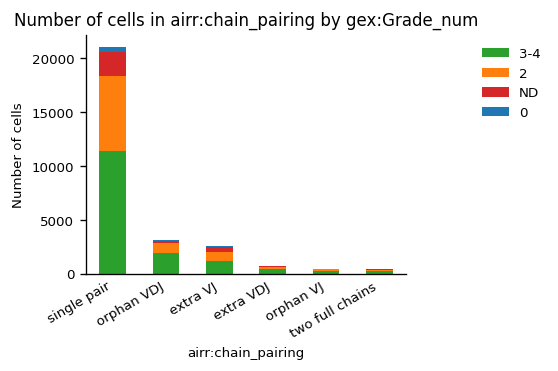

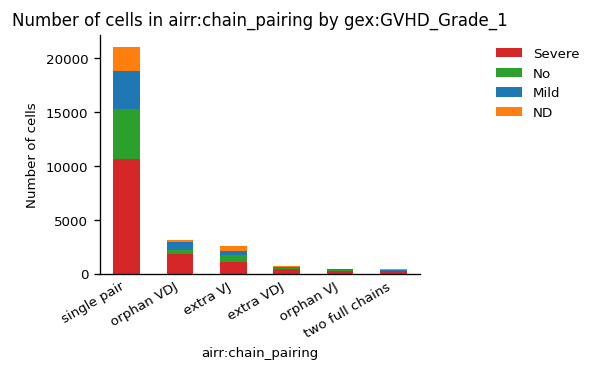

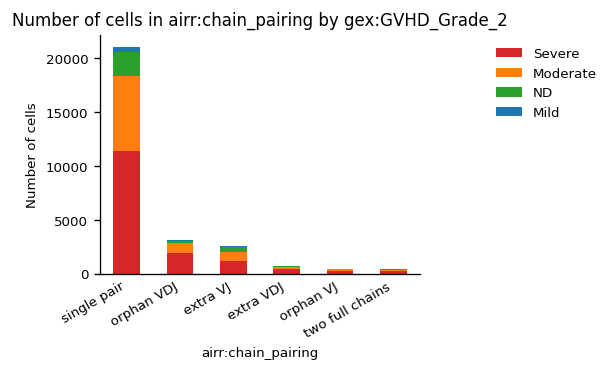

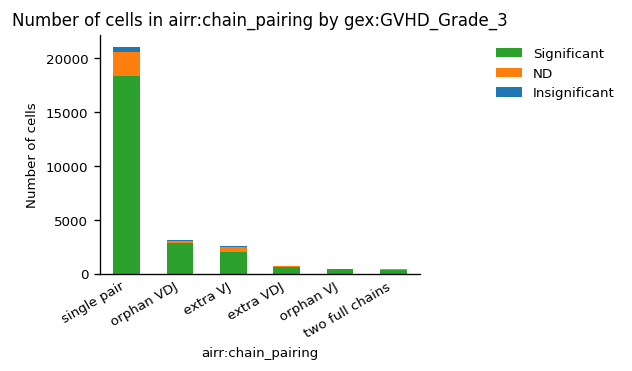

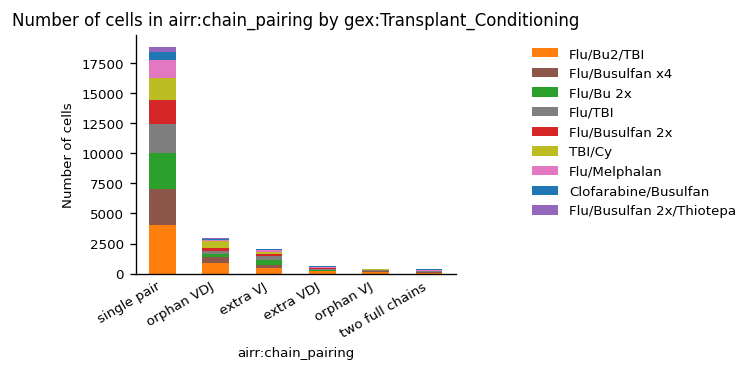

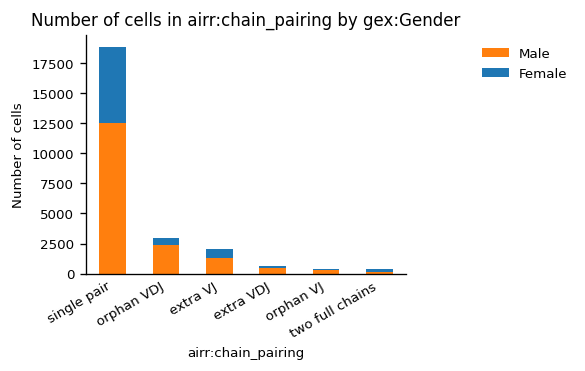

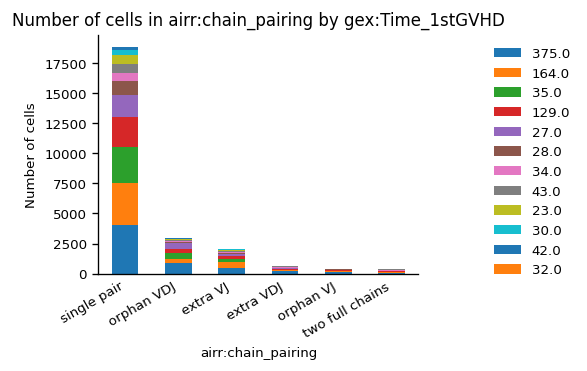

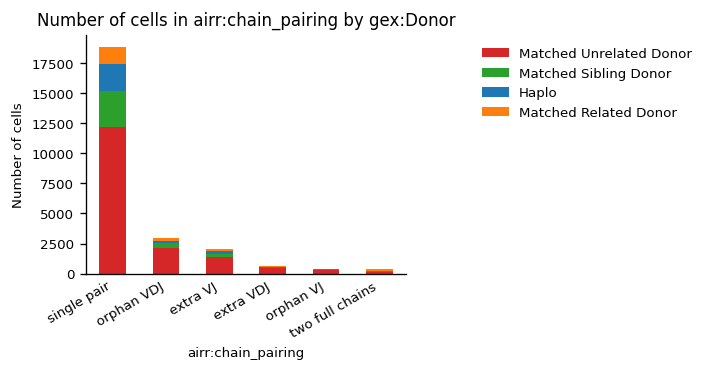

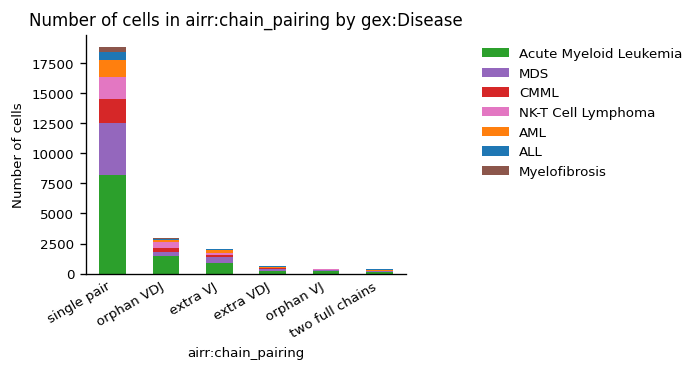

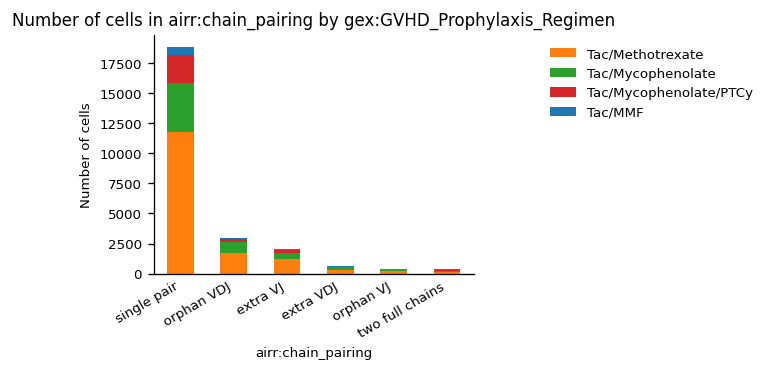

In [14]:

for meta in parameters:
    ax = ir.pl.group_abundance(mdata, groupby="airr:chain_pairing", target_col=f"gex:{meta}")


In [15]:
ir.pp.ir_dist(mdata)

In [16]:
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

In [17]:
ir.tl.clonotype_network(mdata, min_cells=2)

In [18]:
ir.pp.ir_dist(
    mdata,
    metric="identity",
    sequence="aa",
    cutoff=15,
)


In [19]:
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="identity", receptor_arms="all", dual_ir="any")

In [20]:
mdata.write(TCELL_ANN_CONCAT_WITH_TCR_PATH)

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [21]:
# just print the mdata airr obs to csv file
mdata["airr"].obs.to_csv(AIRR_OBS_CSV_PATH)